# black hole evap

C:\Users\jiyan\AppData\Local\Temp\ipykernel_17800\425371645.py:27: RuntimeWarning: divide by zero encountered in divide
  T_values = (ħ * c**3) / (8 * np.pi * G * M_values * k_B)  # Hawking temperature


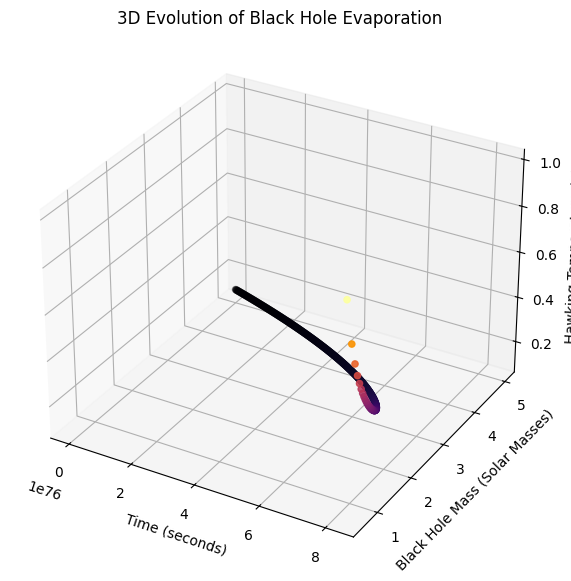

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants
G = 6.67430e-11  # Gravitational constant (m^3/kg/s^2)
c = 3.0e8        # Speed of light (m/s)
ħ = 1.05457e-34  # Reduced Planck constant (J·s)
k_B = 1.3807e-23 # Boltzmann constant (J/K)

# Hawking radiation formula constants
sigma = (ħ * c**4) / (15360 * np.pi * G**2)

# Initial black hole mass (solar masses)
M_sun = 1.989e30  # kg
M_initial = 5 * M_sun  # Initial black hole mass
t_evap = (5120 * np.pi * G**2 * M_initial**3) / (ħ * c**4)  # Evaporation timescale

# Time evolution (normalized 0 to 1)
t_values = np.linspace(0, 1, 500)  # Scaled time (0 to 1, representing full lifetime)

# Compute mass loss due to Hawking radiation
M_values = M_initial * (1 - t_values) ** (1/3)  # Mass loss function
M_values[M_values < 0] = 0  # Prevent negative mass

# Compute temperature evolution
T_values = (ħ * c**3) / (8 * np.pi * G * M_values * k_B)  # Hawking temperature
T_values[M_values <= 0] = np.nan  # Avoid division errors when mass is zero

# 3D Plot
fig = plt.figure(figsize=(21,7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with color gradient based on temperature
ax.scatter(t_values * t_evap, M_values / M_sun, T_values, c=T_values, cmap='inferno', marker='o')

# Labels and Title
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Black Hole Mass (Solar Masses)")
ax.set_zlabel("Hawking Temperature (K)")
ax.set_title("3D Evolution of Black Hole Evaporation")

plt.show()

In [9]:
import numpy as np
import pandas as pd

# Constants
G = 6.67430e-11  # Gravitational constant (m^3/kg/s^2)
c = 3.0e8        # Speed of light (m/s)
ħ = 1.05457e-34  # Reduced Planck constant (J·s)
k_B = 1.3807e-23 # Boltzmann constant (J/K)

# Initial black hole mass (in solar masses)
M_sun = 1.989e30  # kg
M_initial = 5 * M_sun  # Initial black hole mass

# Compute total evaporation timescale
t_evap = (5120 * np.pi * G**2 * M_initial**3) / (ħ * c**4)

# Time evolution (normalized from 0 to 1)
t_values = np.linspace(0, 1, 500)  # 500 points over the lifetime

# Compute mass loss due to Hawking radiation
M_values = M_initial * (1 - t_values) ** (1/3)  # Mass loss function
M_values[M_values < 0] = 0  # Prevent negative mass

# Compute Hawking temperature
T_values = (ħ * c**3) / (8 * np.pi * G * M_values * k_B)  # Temperature evolution
T_values[M_values <= 0] = np.nan  # Avoid division by zero when mass reaches zero

# Compute actual time values
t_actual = t_values * t_evap  # Scale normalized time to actual evaporation timescale

# Create DataFrame
df = pd.DataFrame({
    'Scaled Time (t_scaled)': t_values,
    'Time (s)': t_actual,
    'Mass (Solar Masses)': M_values / M_sun,  # Convert to solar masses
    'Temperature (K)': T_values
})

# Save as CSV file
df.to_csv('black_hole_evolution.csv', index=False)

# Display the first few rows
print("head\n",df.head(),"\n")
print("shape: \n",df.shape,"\n")
print("full\n",df)
# download
#files.download('black_hole_evolution.csv')
#print("File saved locally as 'black_hole_evolution.csv'.")

C:\Users\jiyan\AppData\Local\Temp\ipykernel_17800\1556475974.py:25: RuntimeWarning: divide by zero encountered in divide
  T_values = (ħ * c**3) / (8 * np.pi * G * M_values * k_B)  # Temperature evolution


head
    Scaled Time (t_scaled)      Time (s)  Mass (Solar Masses)  Temperature (K)
0                0.000000  0.000000e+00             5.000000     1.236202e-08
1                0.002004  1.653426e+74             4.996658     1.237029e-08
2                0.004008  3.306851e+74             4.993311     1.237858e-08
3                0.006012  4.960277e+74             4.989960     1.238689e-08
4                0.008016  6.613703e+74             4.986604     1.239523e-08 

shape: 
 (500, 4) 

full
      Scaled Time (t_scaled)      Time (s)  Mass (Solar Masses)  \
0                  0.000000  0.000000e+00             5.000000   
1                  0.002004  1.653426e+74             4.996658   
2                  0.004008  3.306851e+74             4.993311   
3                  0.006012  4.960277e+74             4.989960   
4                  0.008016  6.613703e+74             4.986604   
..                      ...           ...                  ...   
495                0.991984  8.18445

In [16]:
#SCALING
print("if any null values:\n",df.isnull().sum())
print("\nH. Temp max: ", df["Temperature (K)"].max())
print("time: ",df["Time (s)"].min())
print("mass median: ",df["Mass (Solar Masses)"].median())

print("\n")
print("temp ka: \n",df[df["Temperature (K)"] == 9.805197133316721e-08],"\n",df[df["Temperature (K)"] == 7.782390122091344e-08])
print("time ka ka: \n",df[df["Time (s)"] == 0.0],"\n",df[df["Time (s)"] == 5.125619463942009e+75])
print("time ka ka: \n",df[df["Mass (Solar Masses)"] == 3.9658498867303478],"\n",df[df["Mass (Solar Masses)"] == 3.856692233228001])

if any null values:
 Scaled Time (t_scaled)    0
Time (s)                  0
Mass (Solar Masses)       0
Temperature (K)           1
dtype: int64

H. Temp max:  9.805197133316721e-08
time:  0.0
mass median:  3.9685008590625803


temp ka: 
      Scaled Time (t_scaled)      Time (s)  Mass (Solar Masses)  \
498                0.997996  8.234060e+76             0.630381   

     Temperature (K)  
498     9.805197e-08   
      Scaled Time (t_scaled)      Time (s)  Mass (Solar Masses)  \
497                0.995992  8.217525e+76              0.79423   

     Temperature (K)  
497     7.782390e-08  
time ka ka: 
    Scaled Time (t_scaled)  Time (s)  Mass (Solar Masses)  Temperature (K)
0                     0.0       0.0                  5.0     1.236202e-08 
     Scaled Time (t_scaled)      Time (s)  Mass (Solar Masses)  Temperature (K)
31                0.062124  5.125619e+75             4.894238     1.262916e-08
time ka ka: 
      Scaled Time (t_scaled)      Time (s)  Mass (Solar Masses)  

# neutron star collision

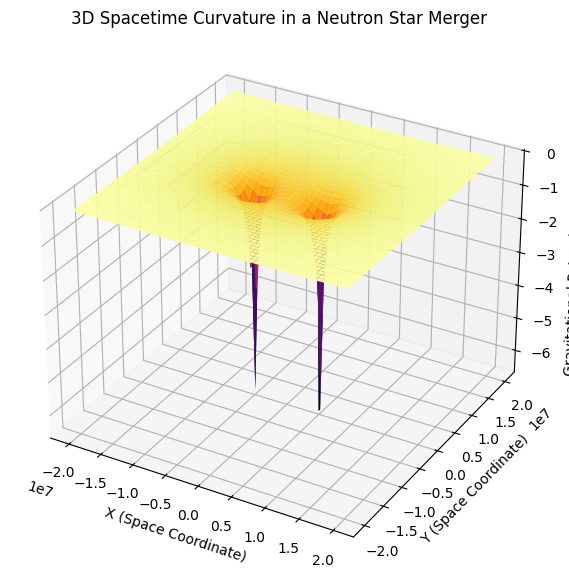

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Constants
G = 6.67430e-11  # Gravitational constant
M1 = 2.0e30  # Mass of first neutron star (approx solar mass)
M2 = 2.0e30  # Mass of second neutron star
d = 1e7  # Initial distance between neutron stars in meters

# Grid setup
x = np.linspace(-2*d, 2*d, 100)
y = np.linspace(-2*d, 2*d, 100)
X, Y = np.meshgrid(x, y)

# Function for gravitational potential (spacetime curvature proxy)
def gravitational_potential(X, Y, M1, M2, d):
    r1 = np.sqrt((X + d/2)**2 + Y**2)  # Distance from first neutron star
    r2 = np.sqrt((X - d/2)**2 + Y**2)  # Distance from second neutron star
    phi = -G * (M1 / r1 + M2 / r2)  # Superposition of potentials
    return phi

# Compute curvature
Z = gravitational_potential(X, Y, M1, M2, d)

# Plotting the 3D graph
fig = plt.figure(figsize=(21,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='inferno', edgecolor='none')

# Labels and title
ax.set_xlabel("X (Space Coordinate)")
ax.set_ylabel("Y (Space Coordinate)")
ax.set_zlabel("Gravitational Potential (Curvature)")
ax.set_title("3D Spacetime Curvature in a Neutron Star Merger")

plt.show()


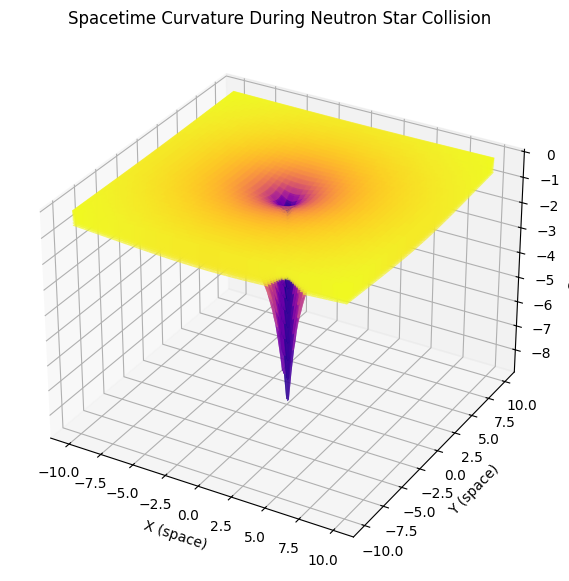

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define spatial grid
x = np.linspace(-10, 10, 100)
y = np.linspace(-10, 10, 100)
X, Y = np.meshgrid(x, y)

# Define a simplified curvature function based on gravitational potential
def curvature(X, Y, t):
    r = np.sqrt(X**2 + Y**2 + 1e-6)  # Avoid division by zero
    return -10 / (r + 1) * np.exp(-0.1 * t)  # Decaying curvature over time

# Time steps for animation
time_steps = np.linspace(0, 20, 20)  # Simulated evolution over time

# Plot
fig = plt.figure(figsize=(21,7))
ax = fig.add_subplot(111, projection='3d')

for t in time_steps:
    Z = curvature(X, Y, t)  # Compute curvature
    ax.plot_surface(X, Y, Z, cmap='plasma', alpha=0.7)

ax.set_xlabel("X (space)")
ax.set_ylabel("Y (space)")
ax.set_zlabel("Curvature")
ax.set_title("Spacetime Curvature During Neutron Star Collision")

plt.show()

In [17]:
import numpy as np
import pandas as pd

# Define spatial grid
x = np.linspace(-8, 8, 200)
y = np.linspace(-8, 8, 200)
X, Y = np.meshgrid(x, y)

# Constants
m1, m2 = 1.4, 1.4  # Neutron star masses (in solar masses)
G = 1  # Scaled gravitational constant
c = 1  # Scaled speed of light
d_initial = 6  # Initial separation
num_frames = 250  # Total frames
merge_frame = num_frames // 2  # Merging happens at half of frames

# Function to compute spacetime curvature
def spacetime_warp(X, Y, d, t):
    r1 = np.sqrt((X + d / 2) ** 2 + Y ** 2)  # Distance from star 1
    r2 = np.sqrt((X - d / 2) ** 2 + Y ** 2)  # Distance from star 2

    # Schwarzschild-like curvature function
    warp = - (G * m1 / (r1 + 0.5)) - (G * m2 / (r2 + 0.5))

    # Gravitational wave contribution
    waves = 0.15 * np.sin(2 * np.pi * (r1 + r2 - c * t) / 1.5) / (1 + r1 + r2)

    # Neutron star visualization (shallow dips)
    star1 = np.exp(-5 * r1) * -1.5
    star2 = np.exp(-5 * r2) * -1.5

    return warp + waves + star1 + star2

# Initialize data storage
data = []

# Iterate through animation frames
for frame in range(num_frames):
    t = frame * 0.1  # Time evolution
    d = d_initial * (1 - frame / merge_frame) if frame < merge_frame else 0.5  # Decreasing separation

    # Compute curvature grid
    Z = spacetime_warp(X, Y, d, t)

    # Store frame data
    data.append({
        "Frame": frame,
        "Time (t)": t,
        "Distance (d)": d,
        "Max Curvature (Z)": np.max(Z),
        "Min Curvature (Z)": np.min(Z)
    })

# Create DataFrame
df1 = pd.DataFrame(data)

# Save as CSV file
df1.to_csv("neutron_star_collision_data.csv", index=False)

# Display first few rows
print("head\n",df1.head(),"\n")
print("shape: \n",df1.shape,"\n")
print("full\n",df1)

head
    Frame  Time (t)  Distance (d)  Max Curvature (Z)  Min Curvature (Z)
0      0       0.0         6.000          -0.235160          -3.998543
1      1       0.1         5.952          -0.234082          -3.871363
2      2       0.2         5.904          -0.234031          -4.018480
3      3       0.3         5.856          -0.235175          -4.054153
4      4       0.4         5.808          -0.237278          -3.946946 

shape: 
 (250, 5) 

full
      Frame  Time (t)  Distance (d)  Max Curvature (Z)  Min Curvature (Z)
0        0       0.0         6.000          -0.235160          -3.998543
1        1       0.1         5.952          -0.234082          -3.871363
2        2       0.2         5.904          -0.234031          -4.018480
3        3       0.3         5.856          -0.235175          -4.054153
4        4       0.4         5.808          -0.237278          -3.946946
..     ...       ...           ...                ...                ...
245    245      24.5         

In [22]:
#SCALING
md=df1["Time (t)"].median()
print(f"median= {md}\n")
print("\n")
print("jab bohot dur he:\n",df1[df1["Time (t)"] == 0.0],"\n",df1[df1["Time (t)"] == 1.5])
print("\nin between:\n",df1[df1["Time (t)"] == 12.5],"\n",df1[df1["Time (t)"] == 14])
print("\ncolided/ almost collided:\n",df1[df1["Time (t)"] == 23.4],"\n",df1[df1["Time (t)"] == 24.9])

median= 12.45



jab bohot dur he:
    Frame  Time (t)  Distance (d)  Max Curvature (Z)  Min Curvature (Z)
0      0       0.0           6.0           -0.23516          -3.998543 
     Frame  Time (t)  Distance (d)  Max Curvature (Z)  Min Curvature (Z)
15     15       1.5          5.28          -0.233547          -3.979018

in between:
      Frame  Time (t)  Distance (d)  Max Curvature (Z)  Min Curvature (Z)
125    125      12.5           0.5          -0.237834          -5.196212 
      Frame  Time (t)  Distance (d)  Max Curvature (Z)  Min Curvature (Z)
140    140      14.0           0.5          -0.237834          -5.196212

colided/ almost collided:
 Empty DataFrame
Columns: [Frame, Time (t), Distance (d), Max Curvature (Z), Min Curvature (Z)]
Index: [] 
 Empty DataFrame
Columns: [Frame, Time (t), Distance (d), Max Curvature (Z), Min Curvature (Z)]
Index: []


# waveform

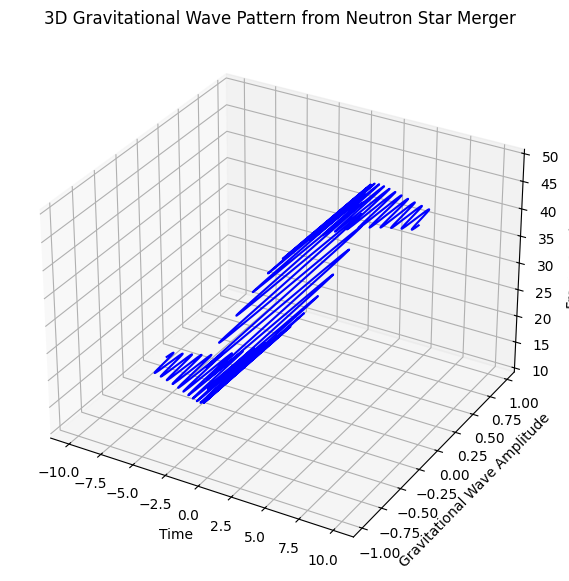

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define time range
t = np.linspace(-10, 10, 1000)

# Define gravitational wave amplitude function
def gw_amplitude(t):
    return np.exp(-0.2 * np.abs(t)) * np.sin(10 * t)  # Decaying sinusoidal wave

# Define frequency evolution
def gw_frequency(t):
    return 30 + 20 * np.tanh(t / 3)  # Frequency increases, then stabilizes

# Compute amplitude and frequency
h = gw_amplitude(t)
f = gw_frequency(t)

# Plot 3D waveform
fig = plt.figure(figsize=(21, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot3D(t, h, f, color='blue')

# Labels
ax.set_xlabel("Time")
ax.set_ylabel("Gravitational Wave Amplitude")
ax.set_zlabel("Frequency (Hz)")
ax.set_title("3D Gravitational Wave Pattern from Neutron Star Merger")

plt.show()

In [24]:
import numpy as np
import pandas as pd

# Define time range
t = np.linspace(-10, 10, 1000)

# Define gravitational wave amplitude function
def gw_amplitude(t):
    return np.exp(-0.2 * np.abs(t)) * np.sin(10 * t)  # Decaying sinusoidal wave

# Define frequency evolution
def gw_frequency(t):
    return 30 + 20 * np.tanh(t / 3)  # Frequency increases, then stabilizes

# Compute amplitude and frequency
h = gw_amplitude(t)
f = gw_frequency(t)

# Create a DataFrame
df2 = pd.DataFrame({'Time (t)': t, 'Amplitude (h)': h, 'Frequency (f)': f})
df2.to_csv("waveform_num.csv", index=False)
# Display the rows
print("head\n",df2.head(),"\n")
print("tail\n",df2.tail(),"\n")
print("full\n",df2)

#download
#data.to_csv('gravitational_wave.csv', index=False)
#from google.colab import files
#files.download('gravitational_wave.csv')

head
    Time (t)  Amplitude (h)  Frequency (f)
0 -10.00000       0.068529      10.050841
1  -9.97998       0.090731      10.051523
2  -9.95996       0.109471      10.052214
3  -9.93994       0.123969      10.052915
4  -9.91992       0.133610      10.053625 

tail
      Time (t)  Amplitude (h)  Frequency (f)
995   9.91992      -0.133610      49.946375
996   9.93994      -0.123969      49.947085
997   9.95996      -0.109471      49.947786
998   9.97998      -0.090731      49.948477
999  10.00000      -0.068529      49.949159 

full
      Time (t)  Amplitude (h)  Frequency (f)
0   -10.00000       0.068529      10.050841
1    -9.97998       0.090731      10.051523
2    -9.95996       0.109471      10.052214
3    -9.93994       0.123969      10.052915
4    -9.91992       0.133610      10.053625
..        ...            ...            ...
995   9.91992      -0.133610      49.946375
996   9.93994      -0.123969      49.947085
997   9.95996      -0.109471      49.947786
998   9.97998      -0.

In [8]:
# FINDING MEDIAN OF FREQ
m=data['Frequency (f)'].median()
print(m)
print(data.columns)

30.0
Index(['Time (t)', 'Amplitude (h)', 'Frequency (f)'], dtype='object')


# nsc gif

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D

# Define spatial grid
x = np.linspace(-8, 8, 200)  # Widened field of view
y = np.linspace(-8, 8, 200)
X, Y = np.meshgrid(x, y)

# Constants
m1, m2 = 1.4, 1.4  # Neutron star masses (in solar masses)
G = 1  # Scaled gravitational constant
c = 1  # Scaled speed of light
d_initial = 6  # Increased initial separation
num_frames = 250  # More animation frames for smooth motion
merge_frame = num_frames // 2  # Frame at which stars merge

# Function to compute spacetime curvature
def spacetime_warp(X, Y, d, t):
    r1 = np.sqrt((X + d / 2) ** 2 + Y ** 2)  # Distance from star 1
    r2 = np.sqrt((X - d / 2) ** 2 + Y ** 2)  # Distance from star 2

    # Schwarzschild-like curvature function (simplified)
    warp = - (G * m1 / (r1 + 0.5)) - (G * m2 / (r2 + 0.5))

    # Add merging effect and gravitational waves
    waves = 0.15 * np.sin(2 * np.pi * (r1 + r2 - c * t) / 1.5) / (1 + r1 + r2)

    # Neutron star visualization (shallow dips at centers)
    star1 = np.exp(-5 * r1) * -1.5  
    star2 = np.exp(-5 * r2) * -1.5  

    return warp + waves + star1 + star2

# Initialize figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Initialize surface
Z = spacetime_warp(X, Y, d_initial, 0)
surf = ax.plot_surface(X, Y, Z, cmap="inferno", edgecolor="none")

ax.set_zlim(-3, 1)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Spacetime Curvature")
ax.set_title("Neutron Star Collision - Spacetime Curvature")

# Update function for animation
def update(frame):
    # Stars move together slowly, then merge
    if frame < merge_frame:
        d = d_initial * (1 - frame / merge_frame)  # Gradually decrease distance
    else:
        d = 0.5  # Keep at merged state after collision

    Z = spacetime_warp(X, Y, d, frame * 0.1)  # Update curvature
    ax.clear()
    ax.set_zlim(-3, 1)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Spacetime Curvature")
    ax.set_title("Neutron Star Collision - Spacetime Curvature")
    ax.plot_surface(X, Y, Z, cmap="inferno", edgecolor="none")

# Create animation
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=50, blit=False)

# Save animation
ani.save("neutron_star_collision.gif", writer="pillow", fps=30)

plt.show()

# black hole gif

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm  # Import colormap

# Define constants
M_sun = 1.989e30  # Solar mass in kg
initial_mass = 5 * M_sun  # Example: A black hole with 5 solar masses
evaporation_rate = 1e-5  # Arbitrary small evaporation rate
time_steps = 100  # Number of steps in animation
time = np.linspace(0, 1e77, time_steps)  # Time range

# Function to compute mass evolution    
def compute_evolution(M_initial, M_sun, time_steps):
    mass_values = np.zeros(time_steps)
    M = M_initial  

    for i in range(time_steps):
        mass_values[i] = M / M_sun  # Convert to solar masses
        M -= evaporation_rate  # Simulate mass loss
        if M < 0:
            M = 0

    return mass_values

# Compute mass evolution
mass_values = compute_evolution(initial_mass, M_sun, time_steps)

# Normalize mass values for colormap (between 0 and 1)
colors = cm.inferno((mass_values - min(mass_values)) / (max(mass_values) - min(mass_values)))

# Set up 3D plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Initialize scatter plot with empty data
sc = ax.scatter([], [], [], c=[], cmap="inferno")

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Black Hole Mass (Solar Masses)")
ax.set_zlabel("Hawking Radiation Intensity")
ax.set_title("3D Evolution of Black Hole Evaporation")

# Update function for animation
def update(frame):
    # Update data dynamically
    sc._offsets3d = (time[:frame], mass_values[:frame], np.zeros(frame))  # Update points
    sc.set_array(mass_values[:frame])  # Update color
    return sc,

# Create animation
ani = animation.FuncAnimation(fig, update, frames=time_steps, interval=50, blit=False)

# Save animation as GIF using Pillow
ani.save("black_hole_evolution_colored.gif", writer="pillow", fps=30)

plt.show()


# output saved